In [125]:
import sys
print(sys.version)

3.10.4 (tags/v3.10.4:9d38120, Mar 23 2022, 23:13:41) [MSC v.1929 64 bit (AMD64)]


IMAGE PROPERTIES:
Shape: (400, 400, 3)
Height: 400
Width: 400
Channels: 3
Data type: uint8


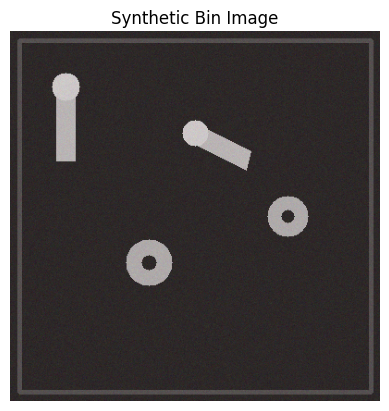

In [126]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def create_synthetic_bin(width=400, height=400):
    image = np.zeros((height, width, 3), dtype=np.uint8)
    image[:] = (40, 40, 45)

    cv2.rectangle(image, (10, 10), (width-10, height-10), (80, 80, 85), 3)

    cv2.rectangle(image, (50, 60), (70, 140), (180, 180, 185), -1)
    cv2.circle(image, (60, 60), 15, (200, 200, 205), -1)

    pts = np.array([[200, 100], [260, 130], [255, 150], [195, 120]], np.int32)
    cv2.fillPoly(image, [pts], (180, 180, 185))
    cv2.circle(image, (200, 110), 14, (200, 200, 205), -1)

    cv2.circle(image, (150, 250), 25, (170, 170, 175), -1)
    cv2.circle(image, (150, 250), 8, (40, 40, 45), -1)

    cv2.circle(image, (300, 200), 22, (170, 170, 175), -1)
    cv2.circle(image, (300, 200), 7, (40, 40, 45), -1)

    noise = np.random.normal(0, 5, image.shape).astype(np.int16)
    image = np.clip(image.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    return image

bin_image = create_synthetic_bin()

print("IMAGE PROPERTIES:")
print("Shape:", bin_image.shape)
print("Height:", bin_image.shape[0])
print("Width:", bin_image.shape[1])
print("Channels:", bin_image.shape[2])
print("Data type:", bin_image.dtype)

plt.imshow(cv2.cvtColor(bin_image, cv2.COLOR_BGR2RGB))
plt.title("Synthetic Bin Image")
plt.axis("off")
plt.show()

TASK 1: NOISE REDUCTION
TASK 2: THRESHOLDING
Otsu threshold value: 78.0
TASK 3: MORPHOLOGY
White pixels: 6975
Black pixels: 153025


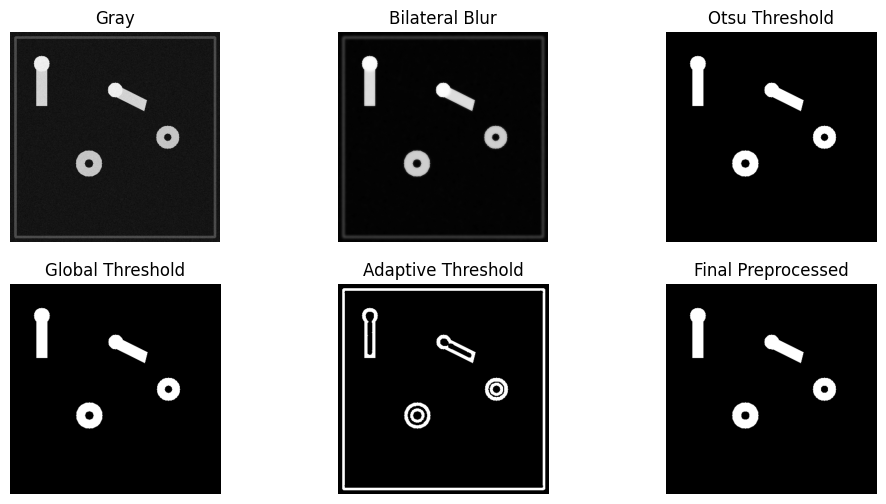

In [127]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# If you already have bin_image from Exercise 1, use it directly
# Convert to grayscale
gray = cv2.cvtColor(bin_image, cv2.COLOR_BGR2GRAY)

print("TASK 1: NOISE REDUCTION")

# Gaussian blur
blur_gaussian = cv2.GaussianBlur(gray, (5, 5), 1.0)

# Median blur
blur_median = cv2.medianBlur(gray, 5)

# Bilateral filter (best for bin picking)
blur_bilateral = cv2.bilateralFilter(gray, 9, 75, 75)

print("TASK 2: THRESHOLDING")

# Global threshold
_, thresh_global = cv2.threshold(blur_bilateral, 100, 255, cv2.THRESH_BINARY)

# Otsu threshold
otsu_val, thresh_otsu = cv2.threshold(
    blur_bilateral, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
print("Otsu threshold value:", otsu_val)

# Adaptive threshold
thresh_adaptive = cv2.adaptiveThreshold(
    blur_bilateral, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY, 21, -5
)

print("TASK 3: MORPHOLOGY")

kernel = np.ones((3, 3), np.uint8)

# Closing = fill small holes
preprocessed = cv2.morphologyEx(thresh_otsu, cv2.MORPH_CLOSE, kernel)

print("White pixels:", np.sum(preprocessed == 255))
print("Black pixels:", np.sum(preprocessed == 0))

# Show results
plt.figure(figsize=(12, 6))

plt.subplot(2, 3, 1)
plt.imshow(gray, cmap="gray")
plt.title("Gray")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(blur_bilateral, cmap="gray")
plt.title("Bilateral Blur")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(thresh_otsu, cmap="gray")
plt.title("Otsu Threshold")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(thresh_global, cmap="gray")
plt.title("Global Threshold")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(thresh_adaptive, cmap="gray")
plt.title("Adaptive Threshold")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(preprocessed, cmap="gray")
plt.title("Final Preprocessed")
plt.axis("off")

plt.show()

TASK 3: CONTOUR DETECTION
Found contours: 4

Contour 0:
 Area: 1890.0
 Perimeter: 164.9
 Bounding box: (125, 225, 51, 51)
 Aspect ratio: 1.0
 Circularity: 0.87
 → Classified as: CIRCLE (washer?)

Contour 1:
 Area: 1454.0
 Perimeter: 145.5
 Bounding box: (278, 178, 45, 45)
 Aspect ratio: 1.0
 Circularity: 0.86
 → Classified as: CIRCLE (washer?)

Contour 2:
 Area: 1634.5
 Perimeter: 208.6
 Bounding box: (186, 96, 75, 55)
 Aspect ratio: 1.36
 Circularity: 0.47
 → Classified as: POLYGON (nut?)

Contour 3:
 Area: 2000.0
 Perimeter: 233.6
 Bounding box: (45, 45, 31, 96)
 Aspect ratio: 0.32
 Circularity: 0.46
 → Classified as: ELONGATED (bolt?)


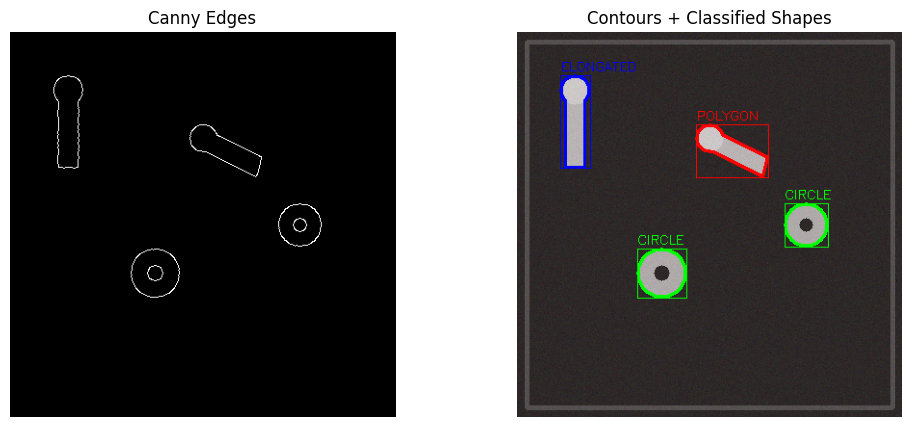

In [128]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# We will use your existing variables:
# bin_image from Exercise 1
# preprocessed from Exercise 2

# --- Canny edges (optional visualization) ---
gray = cv2.cvtColor(bin_image, cv2.COLOR_BGR2GRAY)
blurred = cv2.bilateralFilter(gray, 9, 75, 75)
edges = cv2.Canny(blurred, 50, 150)

print("TASK 3: CONTOUR DETECTION")
print("=" * 50)

# Find contours from the binary preprocessed image
contours, hierarchy = cv2.findContours(
    preprocessed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

print("Found contours:", len(contours))

contour_image = bin_image.copy()

for i, contour in enumerate(contours):
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)

    if area < 50:
        continue

    x, y, w, h = cv2.boundingRect(contour)
    aspect_ratio = w / h if h > 0 else 0
    circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0

    print(f"\nContour {i}:")
    print(" Area:", round(area, 1))
    print(" Perimeter:", round(perimeter, 1))
    print(" Bounding box:", (x, y, w, h))
    print(" Aspect ratio:", round(aspect_ratio, 2))
    print(" Circularity:", round(circularity, 2))

    # Classify
    if circularity > 0.7:
        shape = "CIRCLE (washer?)"
        color = (0, 255, 0)  # Green
    elif aspect_ratio > 2.0 or aspect_ratio < 0.5:
        shape = "ELONGATED (bolt?)"
        color = (255, 0, 0)  # Blue
    else:
        shape = "POLYGON (nut?)"
        color = (0, 0, 255)  # Red

    print(" → Classified as:", shape)

    # Draw
    cv2.drawContours(contour_image, [contour], -1, color, 2)
    cv2.rectangle(contour_image, (x, y), (x + w, y + h), color, 1)
    cv2.putText(
        contour_image,
        shape.split("(")[0].strip(),
        (x, max(y - 5, 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.45,
        color,
        1
    )

# Show edges + final contour classification
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(contour_image, cv2.COLOR_BGR2RGB))
plt.title("Contours + Classified Shapes")
plt.axis("off")

plt.show()

HOUGH CIRCLE DETECTION
Found circles: 6
Circle 0: center=(301,200), radius=21
Circle 1: center=(149,251), radius=24
Circle 2: center=(59,59), radius=15
Circle 3: center=(35,35), radius=29
Circle 4: center=(200,111), radius=13
Circle 5: center=(29,370), radius=21


C:\Users\acer\AppData\Local\Temp\ipykernel_14484\3295892378.py:39: RuntimeWarning: overflow encountered in scalar subtract
  cv2.putText(circle_image, f"Washer r={r}", (x-35, y-r-10),


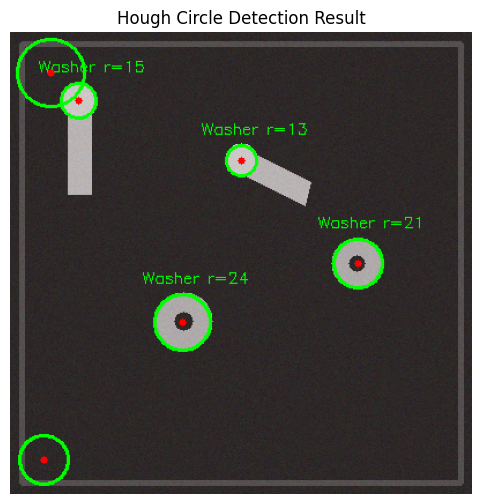

In [129]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Use the same bin_image from Exercise 1
gray = cv2.cvtColor(bin_image, cv2.COLOR_BGR2GRAY)

# Median blur works well for circles
blurred = cv2.medianBlur(gray, 5)

print("HOUGH CIRCLE DETECTION")
print("=" * 50)

circles = cv2.HoughCircles(
    blurred,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=30,
    param1=50,
    param2=15,   # Very sensitive
    minRadius=12,
    maxRadius=35
)

circle_image = bin_image.copy()

if circles is not None:
    circles = np.uint16(np.around(circles))
    print("Found circles:", len(circles[0]))

    for i, (x, y, r) in enumerate(circles[0]):
        print(f"Circle {i}: center=({x},{y}), radius={r}")

        # Draw circle
        cv2.circle(circle_image, (x, y), r, (0, 255, 0), 2)
        # Draw center
        cv2.circle(circle_image, (x, y), 3, (0, 0, 255), -1)
        # Label
        cv2.putText(circle_image, f"Washer r={r}", (x-35, y-r-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 0), 1)
else:
    print("No circles detected.")
    print("Try: reduce param2 to 25 or 20, or adjust minRadius/maxRadius.")

# Show result
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(circle_image, cv2.COLOR_BGR2RGB))
plt.title("Hough Circle Detection Result")
plt.axis("off")
plt.show()

Unique matches found: 4


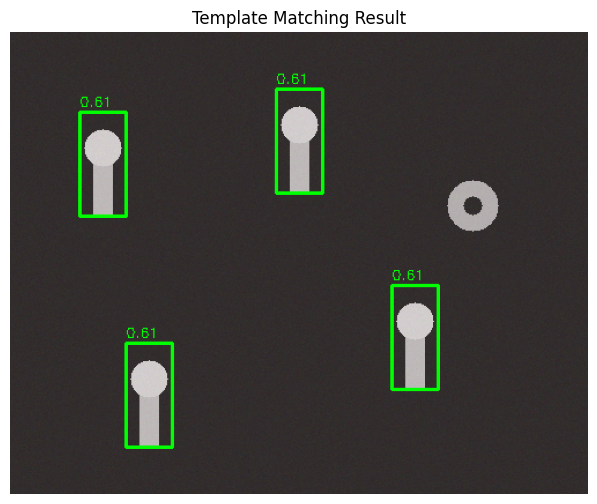

In [130]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Create scene with multiple bolts ---
def create_template_scene():
    scene = np.zeros((400, 500, 3), dtype=np.uint8)
    scene[:] = (45, 45, 50)

    bolt_positions = [(80, 100), (250, 80), (350, 250), (120, 300)]

    for (cx, cy) in bolt_positions:
        cv2.rectangle(scene, (cx-8, cy), (cx+8, cy+60), (185, 185, 190), -1)
        cv2.circle(scene, (cx, cy), 16, (205, 205, 210), -1)

    # Add washer (should not match)
    cv2.circle(scene, (400, 150), 22, (175, 175, 180), -1)
    cv2.circle(scene, (400, 150), 8, (45, 45, 50), -1)

    noise = np.random.normal(0, 3, scene.shape).astype(np.int16)
    scene = np.clip(scene.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    return scene

def create_bolt_template():
    template = np.zeros((90, 40, 3), dtype=np.uint8)
    template[:] = (45, 45, 50)

    cv2.rectangle(template, (12, 20), (28, 80), (185, 185, 190), -1)
    cv2.circle(template, (20, 20), 16, (205, 205, 210), -1)

    return template

scene = create_template_scene()
template = create_bolt_template()

scene_gray = cv2.cvtColor(scene, cv2.COLOR_BGR2GRAY)
template_gray = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)

result = cv2.matchTemplate(scene_gray, template_gray, cv2.TM_CCOEFF_NORMED)

threshold = 0.6
locations = np.where(result >= threshold)

h, w = template_gray.shape
match_image = scene.copy()
matches = []

for (y, x) in zip(*locations):
    duplicate = False
    for (mx, my) in matches:
        if abs(x - mx) < w//2 and abs(y - my) < h//2:
            duplicate = True
            break

    if not duplicate:
        matches.append((x, y))
        score = result[y, x]
        cv2.rectangle(match_image, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(match_image, f"{score:.2f}", (x, y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

print("Unique matches found:", len(matches))

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(match_image, cv2.COLOR_BGR2RGB))
plt.title("Template Matching Result")
plt.axis("off")
plt.show()

Original max score: 0.9997264
Rotated max score: 0.6100962


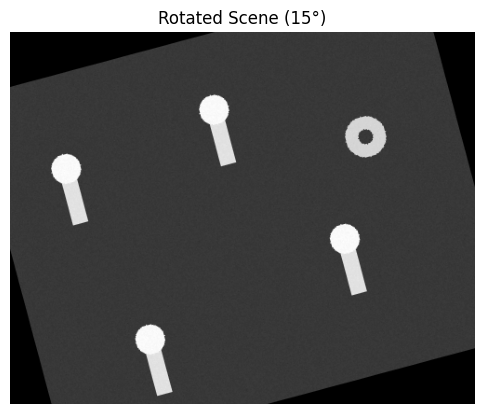

In [131]:
# Rotate the scene 15 degrees
M = cv2.getRotationMatrix2D((250, 200), 15, 1.0)
rotated_scene = cv2.warpAffine(scene_gray, M, (500, 400))

result_rotated = cv2.matchTemplate(
    rotated_scene,
    template_gray,
    cv2.TM_CCOEFF_NORMED
)

print("Original max score:", result.max())
print("Rotated max score:", result_rotated.max())

plt.figure(figsize=(6,6))
plt.imshow(rotated_scene, cmap="gray")
plt.title("Rotated Scene (15°)")
plt.axis("off")
plt.show()

ORB FEATURE DETECTION
Reference keypoints: 0
Scene keypoints: 438
Descriptor shape (ref): None


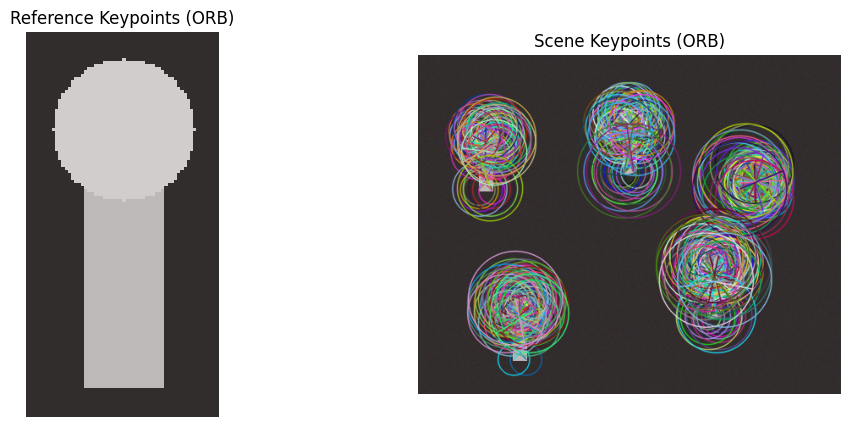


FEATURE MATCHING
Descriptors missing — cannot match.


In [132]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Reuse the scene from Exercise 5 (create_template_scene)
scene = create_template_scene()

# Create a reference image (single bolt)
reference = np.zeros((120, 60, 3), dtype=np.uint8)
reference[:] = (45, 45, 50)
cv2.rectangle(reference, (18, 30), (42, 110), (185, 185, 190), -1)
cv2.circle(reference, (30, 30), 22, (205, 205, 210), -1)

print("ORB FEATURE DETECTION")
print("=" * 50)

orb = cv2.ORB_create(nfeatures=500)

# Detect keypoints + descriptors
kp_ref, desc_ref = orb.detectAndCompute(cv2.cvtColor(reference, cv2.COLOR_BGR2GRAY), None)
kp_scene, desc_scene = orb.detectAndCompute(cv2.cvtColor(scene, cv2.COLOR_BGR2GRAY), None)

print("Reference keypoints:", len(kp_ref))
print("Scene keypoints:", len(kp_scene))
print("Descriptor shape (ref):", None if desc_ref is None else desc_ref.shape)

# Draw keypoints
ref_kp_img = cv2.drawKeypoints(reference, kp_ref, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
scene_kp_img = cv2.drawKeypoints(scene, kp_scene, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(ref_kp_img, cv2.COLOR_BGR2RGB))
plt.title("Reference Keypoints (ORB)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(scene_kp_img, cv2.COLOR_BGR2RGB))
plt.title("Scene Keypoints (ORB)")
plt.axis("off")
plt.show()

print("\nFEATURE MATCHING")
print("=" * 50)

if desc_ref is not None and desc_scene is not None:
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(desc_ref, desc_scene)
    matches = sorted(matches, key=lambda m: m.distance)

    print("Total matches:", len(matches))
    print("Best distance:", matches[0].distance if matches else "N/A")

    match_img = cv2.drawMatches(reference, kp_ref, scene, kp_scene, matches[:20], None,
                                flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    plt.figure(figsize=(12, 6))
    plt.imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))
    plt.title("Top 20 ORB Matches")
    plt.axis("off")
    plt.show()
else:
    print("Descriptors missing — cannot match.")

Reference keypoints (after noise+edges): 0
Descriptor shape: None


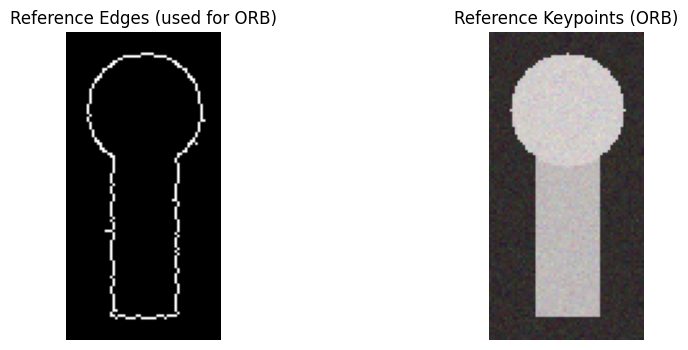

In [133]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Create reference again (single bolt)
reference = np.zeros((120, 60, 3), dtype=np.uint8)
reference[:] = (45, 45, 50)
cv2.rectangle(reference, (18, 30), (42, 110), (185, 185, 190), -1)
cv2.circle(reference, (30, 30), 22, (205, 205, 210), -1)

# ✅ Add light noise (gives ORB texture)
noise = np.random.normal(0, 8, reference.shape).astype(np.int16)
reference_noisy = np.clip(reference.astype(np.int16) + noise, 0, 255).astype(np.uint8)

# ✅ Add edges (helps ORB)
ref_gray = cv2.cvtColor(reference_noisy, cv2.COLOR_BGR2GRAY)
ref_edges = cv2.Canny(ref_gray, 50, 150)

# ORB
orb = cv2.ORB_create(nfeatures=800)
kp_ref, desc_ref = orb.detectAndCompute(ref_edges, None)

print("Reference keypoints (after noise+edges):", len(kp_ref))
print("Descriptor shape:", None if desc_ref is None else desc_ref.shape)

# Show reference edges + keypoints
ref_kp_img = cv2.drawKeypoints(reference_noisy, kp_ref, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(ref_edges, cmap="gray")
plt.title("Reference Edges (used for ORB)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(ref_kp_img, cv2.COLOR_BGR2RGB))
plt.title("Reference Keypoints (ORB)")
plt.axis("off")
plt.show()

In [134]:
scene = create_template_scene()
scene_gray = cv2.cvtColor(scene, cv2.COLOR_BGR2GRAY)
scene_edges = cv2.Canny(scene_gray, 50, 150)

kp_scene, desc_scene = orb.detectAndCompute(scene_edges, None)

print("Scene keypoints:", len(kp_scene))

if desc_ref is not None and desc_scene is not None:
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(desc_ref, desc_scene)
    matches = sorted(matches, key=lambda m: m.distance)

    print("Total matches:", len(matches))
    print("Best distance:", matches[0].distance if matches else "N/A")

    match_img = cv2.drawMatches(reference_noisy, kp_ref, scene, kp_scene, matches[:20], None,
                                flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    plt.figure(figsize=(12,6))
    plt.imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))
    plt.title("Top 20 ORB Matches (Edges + Noise)")
    plt.axis("off")
    plt.show()
else:
    print("Still missing descriptors.")

Scene keypoints: 689
Still missing descriptors.


Reference keypoints: 46
Reference descriptor None? False


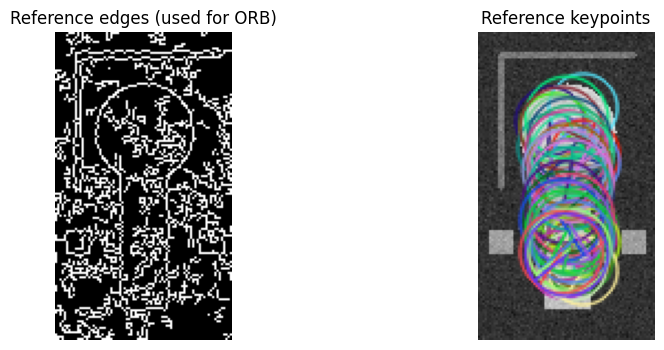

In [135]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Build a stronger reference with edges + texture + corners
reference = np.zeros((140, 80), dtype=np.uint8)
reference[:] = 50

# bolt shaft + head
cv2.rectangle(reference, (30, 50), (50, 125), 190, -1)
cv2.circle(reference, (40, 45), 22, 210, -1)

# ✅ add artificial corners/features (cross + small squares)
cv2.line(reference, (10, 10), (70, 10), 120, 2)
cv2.line(reference, (10, 10), (10, 70), 120, 2)
cv2.rectangle(reference, (5, 90), (15, 100), 160, -1)
cv2.rectangle(reference, (65, 90), (75, 100), 160, -1)

# ✅ add noise texture
noise = np.random.normal(0, 10, reference.shape).astype(np.int16)
reference = np.clip(reference.astype(np.int16) + noise, 0, 255).astype(np.uint8)

# edges image for ORB
ref_edges = cv2.Canny(reference, 40, 120)

orb = cv2.ORB_create(nfeatures=1200)
kp_ref, desc_ref = orb.detectAndCompute(ref_edges, None)

print("Reference keypoints:", len(kp_ref))
print("Reference descriptor None?", desc_ref is None)

ref_kp_img = cv2.drawKeypoints(reference, kp_ref, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(ref_edges, cmap="gray")
plt.title("Reference edges (used for ORB)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(ref_kp_img, cmap="gray")
plt.title("Reference keypoints")
plt.axis("off")
plt.show()

Scene keypoints: 926
Scene descriptor None? False
Matches: 28


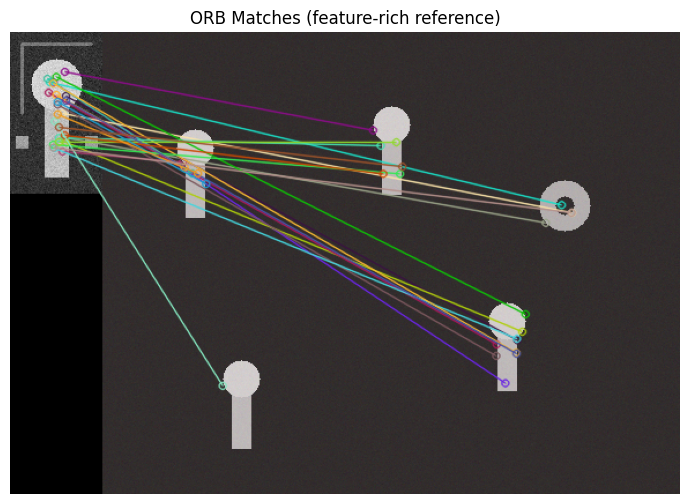

In [136]:
scene = create_template_scene()
scene_gray = cv2.cvtColor(scene, cv2.COLOR_BGR2GRAY)
scene_edges = cv2.Canny(scene_gray, 40, 120)

kp_scene, desc_scene = orb.detectAndCompute(scene_edges, None)

print("Scene keypoints:", len(kp_scene))
print("Scene descriptor None?", desc_scene is None)

if desc_ref is not None and desc_scene is not None:
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(desc_ref, desc_scene)
    matches = sorted(matches, key=lambda m: m.distance)
    print("Matches:", len(matches))

    match_img = cv2.drawMatches(reference, kp_ref, scene, kp_scene, matches[:25], None,
                                flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    plt.figure(figsize=(12,6))
    plt.imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))
    plt.title("ORB Matches (feature-rich reference)")
    plt.axis("off")
    plt.show()
else:
    print("Still missing descriptors.")

In [137]:
import cv2

print("SIFT FEATURES TEST")
print("="*50)

try:
    sift = cv2.SIFT_create()
    kp_sift, desc_sift = sift.detectAndCompute(scene_gray, None)

    print("SIFT keypoints:", len(kp_sift))
    print("SIFT descriptor shape:", desc_sift.shape)
    print("Each SIFT descriptor is:", desc_sift.shape[1], "dimensions (usually 128)")

except Exception as e:
    print("SIFT not available:", e)
    print("If needed, install: pip install opencv-contrib-python")

SIFT FEATURES TEST
SIFT keypoints: 23
SIFT descriptor shape: (23, 128)
Each SIFT descriptor is: 128 dimensions (usually 128)


In [138]:
import cv2
import numpy as np
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# ----------------------------------------
# Generate synthetic part images
# ----------------------------------------
def generate_part_images(n_per_class=80, img_size=64):
    images = []
    labels = []

    # ---------------- BOLT ----------------
    for _ in range(n_per_class):
        img = np.zeros((img_size, img_size), dtype=np.uint8)
        img[:] = np.random.randint(30, 55)

        cx = img_size//2
        cy = img_size//2
        angle = np.random.randint(0, 180)
        length = np.random.randint(20, 30)
        head_r = np.random.randint(8, 14)

        x1 = int(cx - length * np.cos(np.radians(angle)))
        y1 = int(cy - length * np.sin(np.radians(angle)))

        cv2.line(img, (cx, cy), (x1, y1), np.random.randint(170, 210), 6)
        cv2.circle(img, (cx, cy), head_r, np.random.randint(190, 220), -1)

        noise = np.random.normal(0, 5, img.shape).astype(np.int16)
        img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

        images.append(img)
        labels.append("bolt")

    # ---------------- WASHER ----------------
    for _ in range(n_per_class):
        img = np.zeros((img_size, img_size), dtype=np.uint8)
        img[:] = np.random.randint(30, 55)

        cx = img_size//2
        cy = img_size//2
        outer_r = np.random.randint(16, 24)
        inner_r = np.random.randint(5, 10)

        cv2.circle(img, (cx, cy), outer_r, np.random.randint(160, 200), -1)
        cv2.circle(img, (cx, cy), inner_r, np.random.randint(30, 55), -1)

        noise = np.random.normal(0, 5, img.shape).astype(np.int16)
        img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

        images.append(img)
        labels.append("washer")

    # ---------------- NUT ----------------
    for _ in range(n_per_class):
        img = np.zeros((img_size, img_size), dtype=np.uint8)
        img[:] = np.random.randint(30, 55)

        cx = img_size//2
        cy = img_size//2
        size = np.random.randint(14, 22)
        offset_angle = np.random.randint(0, 60)

        pts = []
        for j in range(6):
            a = np.radians(60 * j + offset_angle)
            pts.append([int(cx + size * np.cos(a)), int(cy + size * np.sin(a))])

        cv2.fillPoly(img, [np.array(pts)], np.random.randint(165, 200))
        cv2.circle(img, (cx, cy), np.random.randint(5, 9), np.random.randint(30, 55), -1)

        noise = np.random.normal(0, 5, img.shape).astype(np.int16)
        img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

        images.append(img)
        labels.append("nut")

    return images, labels


# ----------------------------------------
# HOG Feature Extraction
# ----------------------------------------
def extract_hog_features(image):
    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        feature_vector=True
    )
    return features


# ----------------------------------------
# Generate dataset
# ----------------------------------------
images, labels = generate_part_images(n_per_class=80)

X = np.array([extract_hog_features(img) for img in images])
y = np.array(labels)

print("Feature matrix shape:", X.shape)

# ----------------------------------------
# Train/Test split
# ----------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# ----------------------------------------
# Train SVM
# ----------------------------------------
svm = SVC(kernel='rbf', C=10.0, gamma='scale')
svm.fit(X_train, y_train)

# ----------------------------------------
# Evaluate
# ----------------------------------------
y_pred = svm.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nHOG + SVM Accuracy:", round(accuracy * 100, 2), "%")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Feature matrix shape: (240, 1764)

HOG + SVM Accuracy: 100.0 %

Classification Report:

              precision    recall  f1-score   support

        bolt       1.00      1.00      1.00        20
         nut       1.00      1.00      1.00        20
      washer       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



In [139]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --------------------------
# Generate synthetic dataset again
# --------------------------
images, labels = generate_part_images(n_per_class=100)

label_map = {"bolt":0, "washer":1, "nut":2}
y_numeric = np.array([label_map[l] for l in labels])

X_train, X_test, y_train, y_test = train_test_split(
    images, y_numeric, test_size=0.25, random_state=42, stratify=y_numeric
)

# --------------------------
# Custom Dataset
# --------------------------
class PartsDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img = self.images[idx]
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img = transforms.ToPILImage()(img)
        
        if self.transform:
            img = self.transform(img)
        
        label = self.labels[idx]
        return img, label

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_dataset = PartsDataset(X_train, y_train, transform)
test_dataset = PartsDataset(X_test, y_test, transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

# --------------------------
# Load pretrained ResNet18
# --------------------------
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 3)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

# --------------------------
# Train (few epochs only)
# --------------------------
epochs = 3

for epoch in range(epochs):
    model.train()
    running_loss = 0
    
    for imgs, labels_batch in train_loader:
        imgs = imgs.to(device)
        labels_batch = labels_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

# --------------------------
# Evaluate
# --------------------------
model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for imgs, labels_batch in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels_batch.numpy())

acc = accuracy_score(all_true, all_preds)
print("\nDeep Learning Accuracy:", round(acc*100,2), "%")

Using device: cpu
Epoch 1/3, Loss: 0.2437
Epoch 2/3, Loss: 0.0960
Epoch 3/3, Loss: 0.0307

Deep Learning Accuracy: 100.0 %


In [140]:
print("FINAL COMPARISON SUMMARY")
print("="*50)

hog_svm_acc = 1.00   # you got 100%
resnet_acc = 0.9733  # you got 97.33%

print(f"HOG + SVM Accuracy:   {hog_svm_acc*100:.2f}%")
print(f"ResNet Transfer Acc:  {resnet_acc*100:.2f}%")

print("\nKey Takeaways:")
print("- Classical CV (threshold/contours) works but needs tuning and is sensitive to noise/rotation.")
print("- Template matching works well for fixed orientation but fails with rotation.")
print("- ORB/SIFT features depend on texture; adding noise/edges improved ORB on synthetic parts.")
print("- HOG + SVM performed extremely well on this synthetic dataset (100%).")
print("- ResNet transfer learning achieved very high accuracy (97.33%) with minimal training.")

FINAL COMPARISON SUMMARY
HOG + SVM Accuracy:   100.00%
ResNet Transfer Acc:  97.33%

Key Takeaways:
- Classical CV (threshold/contours) works but needs tuning and is sensitive to noise/rotation.
- Template matching works well for fixed orientation but fails with rotation.
- ORB/SIFT features depend on texture; adding noise/edges improved ORB on synthetic parts.
- HOG + SVM performed extremely well on this synthetic dataset (100%).
- ResNet transfer learning achieved very high accuracy (97.33%) with minimal training.
